In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [26]:
import pandas as pd

# Added on_bad_lines and engine parameters to handle formatting errors in the CSV
try:
    df = pd.read_csv("Road.csv", on_bad_lines='skip', engine='python')
    print("Data loaded successfully!")
    display(df.sample(3).T)
except Exception as e:
    print(f"An error occurred: {e}")

Data loaded successfully!


,823525,375294,849136
Accident_Index,20093102B0184,200691NL05388,200943N315129
1st_Road_Class,A,Unclassified,A
1st_Road_Number,57.0,0.0,421.0
2nd_Road_Class,Unclassified,Unclassified,Unclassified
2nd_Road_Number,0.0,0.0,1941.0
Accident_Severity,Slight,Fatal,Serious
Carriageway_Hazards,NaN,NaN,NaN
Date,2009-01-27,2006-08-05,2009-12-23
Day_of_Week,Tuesday,Saturday,Wednesday
Did_Police_Officer_Attend_Scene_of_Accident,1.0,1.0,1.0


In [ ]:
df.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,741
Vehicle_driver_relation,579
Driving_experience,829
Type_of_vehicle,950
Owner_of_vehicle,482
Service_year_of_vehicle,3928


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

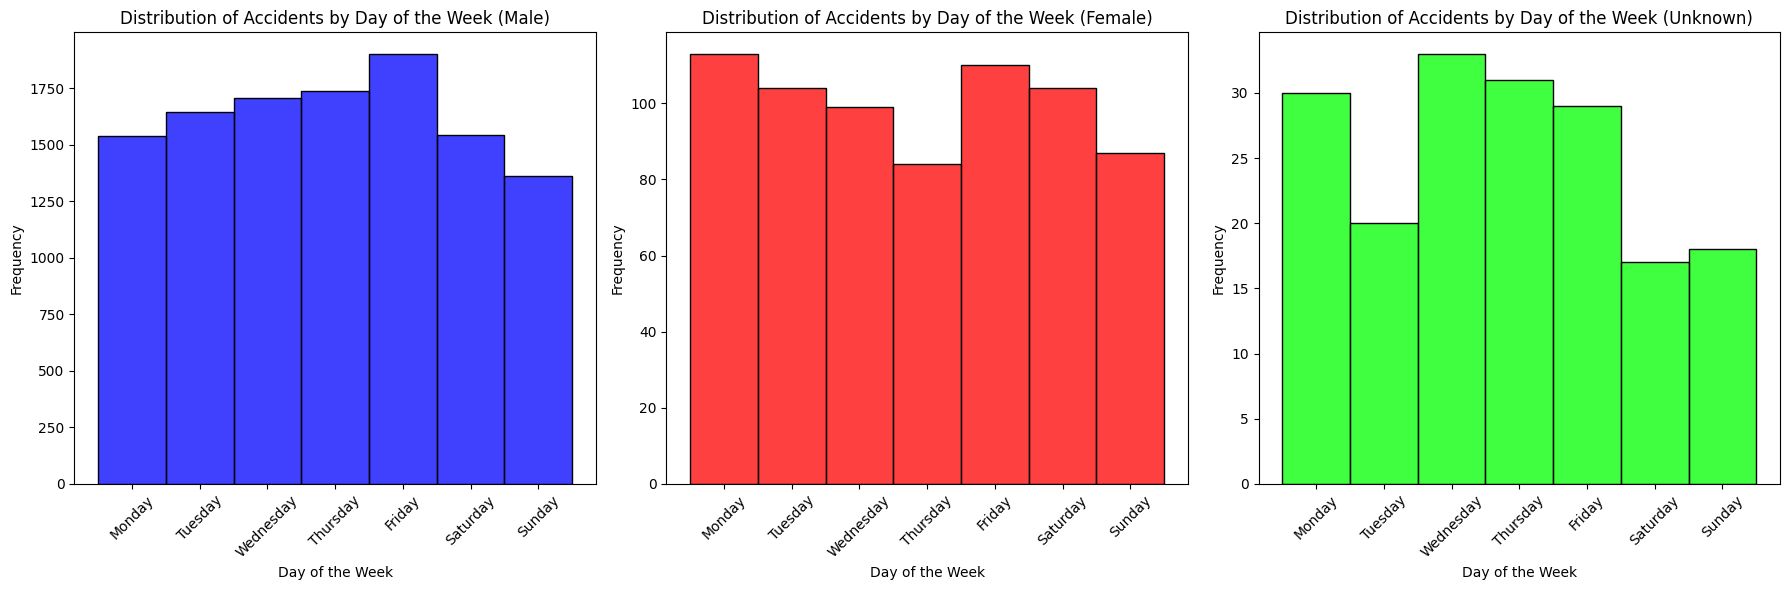

In [ ]:
days_ordered = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df['Day_of_week'] = pd.Categorical(df['Day_of_week'], categories=days_ordered, ordered=True)

custom_colors = {'Male': '#0000FF', 'Female': '#FF0000', 'Unknown': '#00FF00'}

genders = ['Male', 'Female', 'Unknown']

plt.figure(figsize=(18, 6))

for i, gender in enumerate(genders):
    plt.subplot(1, 3, i+1)

    color_bin = custom_colors[gender]

    sns.histplot(data=df[df['Sex_of_driver'] == gender], x='Day_of_week', common_norm=False, color=color_bin)

    plt.xlabel("Day of the Week")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Accidents by Day of the Week ({gender})")

    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


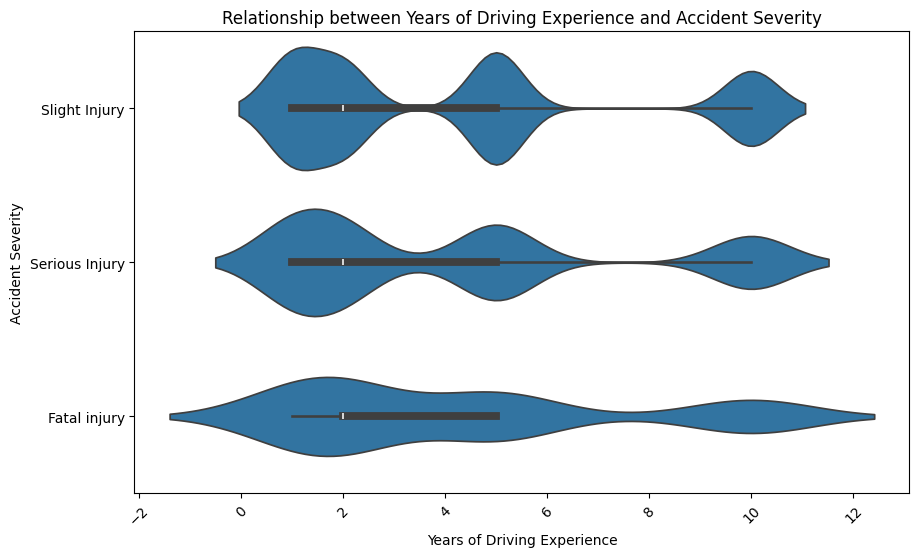

In [ ]:
df_filtered = df[df['Driving_experience'] != 'Unknown']

df_filtered['Driving_experience'] = df_filtered['Driving_experience'].str.extract(r'(\d+)').astype(float)

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_filtered, x='Driving_experience', y='Accident_severity')
plt.xlabel("Years of Driving Experience")
plt.ylabel("Accident Severity")
plt.title("Relationship between Years of Driving Experience and Accident Severity")
plt.xticks(rotation=45)
plt.show()


<ipython-input-50-c57eaf5f3495>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Light_conditions', order=df['Light_conditions'].value_counts().index, palette="Set1")


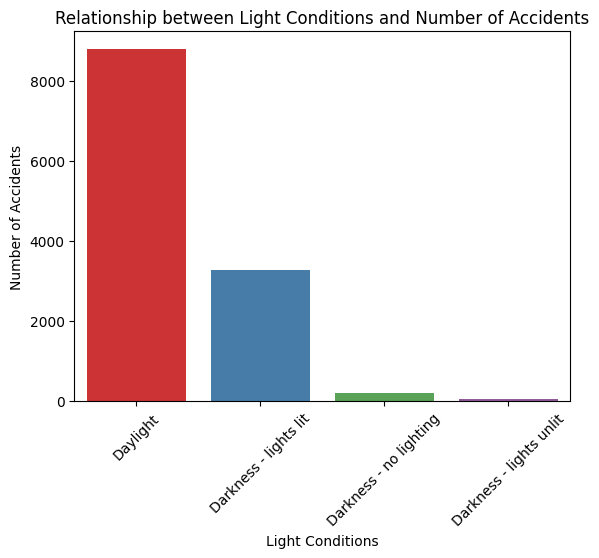

In [ ]:
sns.countplot(data=df, x='Light_conditions', order=df['Light_conditions'].value_counts().index, palette="Set1")
plt.xlabel("Light Conditions")
plt.ylabel("Number of Accidents")
plt.title("Relationship between Light Conditions and Number of Accidents")
plt.xticks(rotation=45)
plt.show()

<ipython-input-51-49e551f36f36>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Vehicle_movement', order=df['Vehicle_movement'].value_counts().index, palette="Set2")


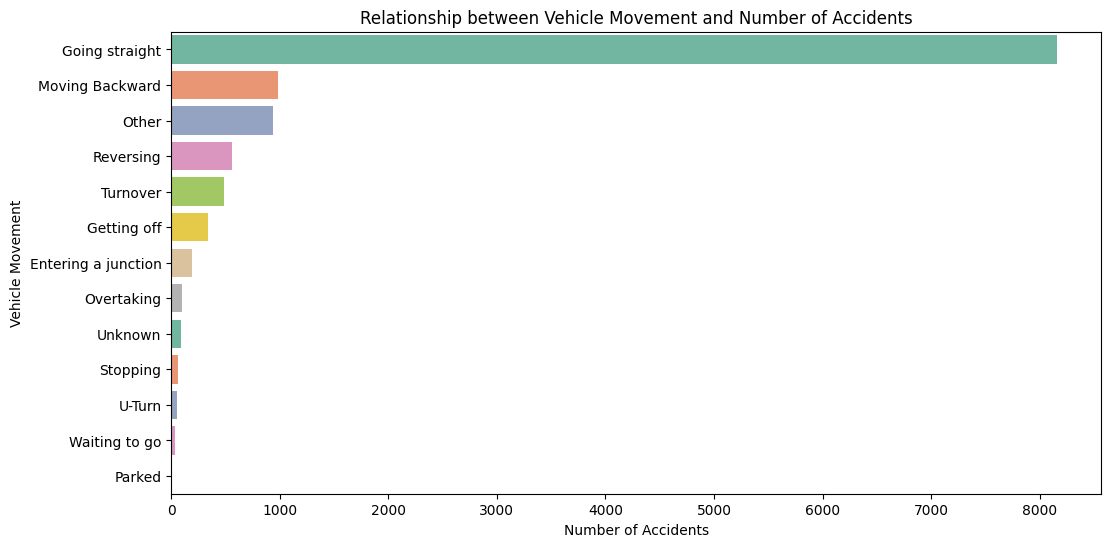

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Vehicle_movement', order=df['Vehicle_movement'].value_counts().index, palette="Set2")
plt.ylabel("Vehicle Movement")
plt.xlabel("Number of Accidents")
plt.title("Relationship between Vehicle Movement and Number of Accidents")
plt.show()

<ipython-input-52-30e08dc69e8d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Cause_of_accident', order=df['Cause_of_accident'].value_counts().index, palette="Set3")


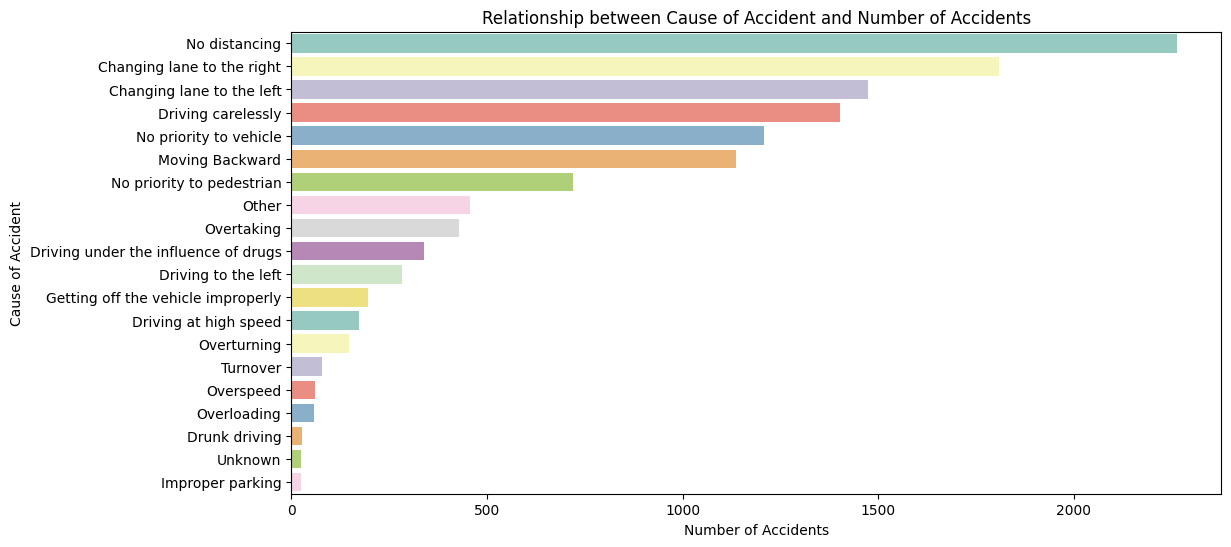

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Cause_of_accident', order=df['Cause_of_accident'].value_counts().index, palette="Set3")
plt.ylabel("Cause of Accident")
plt.xlabel("Number of Accidents")
plt.title("Relationship between Cause of Accident and Number of Accidents")
plt.show()

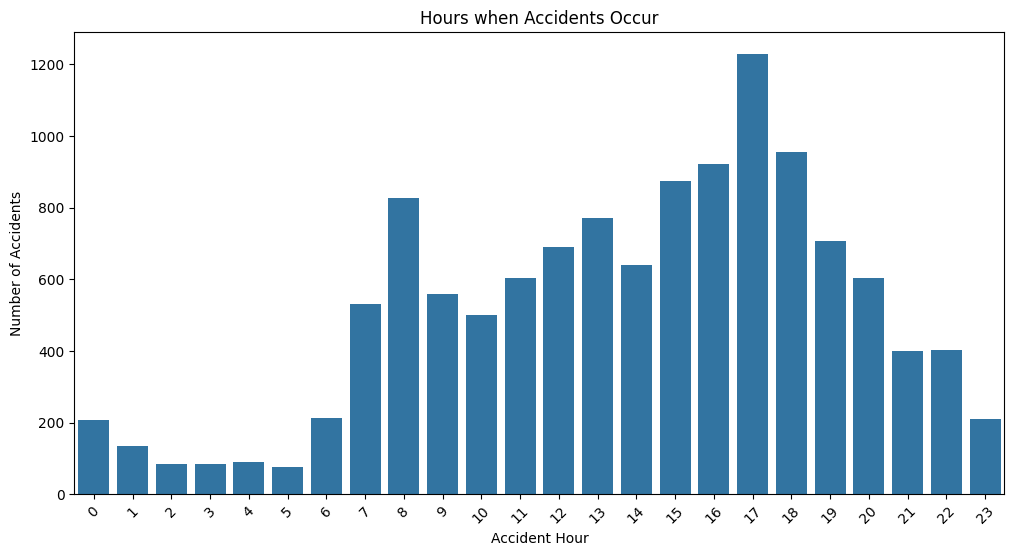

In [ ]:
df[['Hour', 'Minute', 'Second']] = df['Time'].str.split(":", expand=True)
df['Hour'] = df['Hour'].astype(int)

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Hour')
plt.xlabel("Accident Hour")
plt.ylabel("Number of Accidents")
plt.title("Hours when Accidents Occur")
plt.xticks(rotation=45)
plt.show()

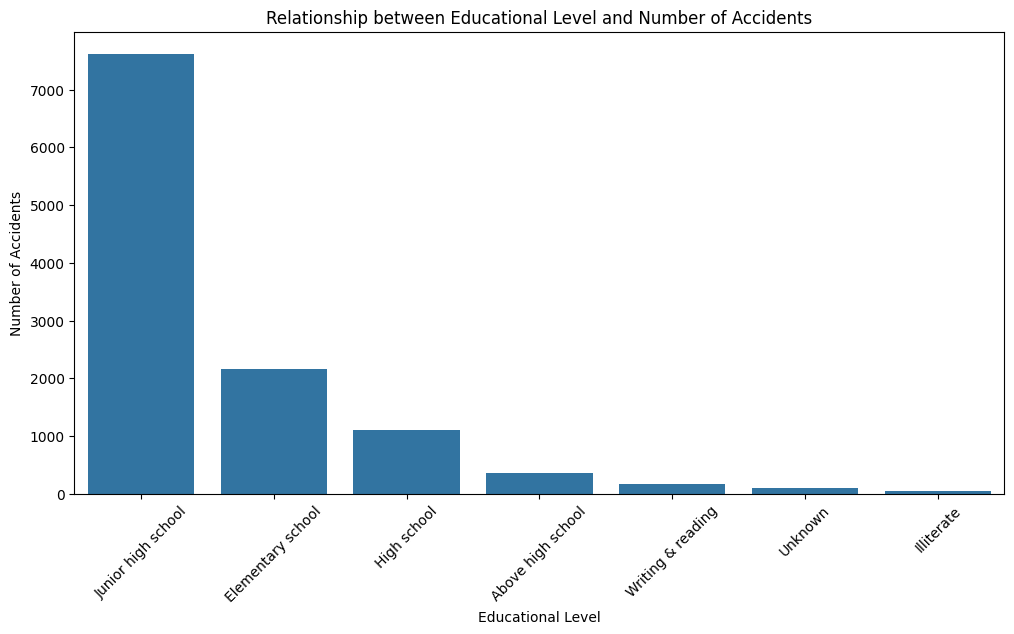

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Educational_level', order=df['Educational_level'].value_counts().index)
plt.xlabel("Educational Level")
plt.ylabel("Number of Accidents")
plt.title("Relationship between Educational Level and Number of Accidents")
plt.xticks(rotation=45)
plt.show()

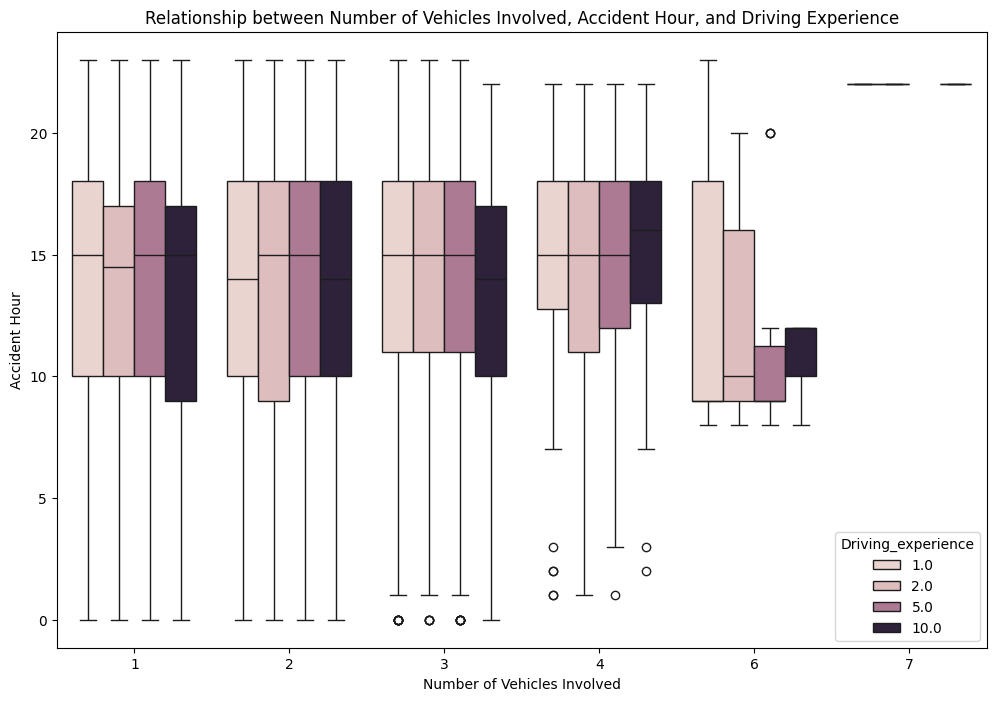

In [ ]:
df_filtered = df[df['Driving_experience'] != 'Unknown']
df_filtered['Driving_experience'] = df_filtered['Driving_experience'].str.extract(r'(\d+)').astype(float)

plt.figure(figsize=(12, 8))
sns.boxplot(data=df_filtered, x='Number_of_vehicles_involved', y='Hour', hue='Driving_experience')
plt.xlabel("Number of Vehicles Involved")
plt.ylabel("Accident Hour")
plt.title("Relationship between Number of Vehicles Involved, Accident Hour, and Driving Experience")
plt.show()

In [ ]:
df = df.drop(['Time', 'Minute', 'Second'], axis=1)

non_numeric_columns = df.select_dtypes(exclude=['int', 'float'])
non_numeric_columns.columns

Index(['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,741
Vehicle_driver_relation,579
Driving_experience,829
Type_of_vehicle,950
Owner_of_vehicle,482
Service_year_of_vehicle,3928
Defect_of_vehicle,4427


In [ ]:
# unique eleents in each column
for column in non_numeric_columns.columns:
    unique_elements = df[column].unique()
    print(f"Unique elements in column '{column}': {unique_elements}")

Unique elements in column 'Day_of_week': ['Monday', 'Sunday', 'Friday', 'Wednesday', 'Saturday', 'Thursday', 'Tuesday']
Categories (7, object): ['Monday' < 'Tuesday' < 'Wednesday' < 'Thursday' < 'Friday' < 'Saturday' <
                         'Sunday']
Unique elements in column 'Age_band_of_driver': ['18-30' '31-50' 'Under 18' 'Over 51' 'Unknown']
Unique elements in column 'Sex_of_driver': ['Male' 'Female' 'Unknown']
Unique elements in column 'Educational_level': ['Above high school' 'Junior high school' nan 'Elementary school'
 'High school' 'Unknown' 'Illiterate' 'Writing & reading']
Unique elements in column 'Vehicle_driver_relation': ['Employee' 'Unknown' 'Owner' nan 'Other']
Unique elements in column 'Driving_experience': ['1-2yr' 'Above 10yr' '5-10yr' '2-5yr' nan 'No Licence' 'Below 1yr'
 'unknown']
Unique elements in column 'Type_of_vehicle': ['Automobile' 'Public (> 45 seats)' 'Lorry (41?100Q)' nan
 'Public (13?45 seats)' 'Lorry (11?40Q)' 'Long lorry' 'Public (12 seats)'
 'Tax

In [27]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

label_encoders = {}
label_mappings = {}

# Based on your data load, the target is 'Accident_Severity'
target_col = 'Accident_Severity'

if 'df' in locals():
    # Drop columns that are unique IDs or have too many missing values for the model
    df_ml = df.drop(columns=['Accident_Index', 'Date', 'LSOA_of_Accident_Location'], errors='ignore').copy()

    # Fill missing values for categorical columns
    for col in df_ml.columns:
        if df_ml[col].dtype == 'object' or df_ml[col].dtype.name == 'category':
            df_ml[col] = df_ml[col].fillna(df_ml[col].mode()[0] if not df_ml[col].mode().empty else 'Unknown')
            le = LabelEncoder()
            df_ml[col] = le.fit_transform(df_ml[col].astype(str))
            label_encoders[col] = le
            label_mappings[col] = dict(zip(le.transform(le.classes_), le.classes_))
        else:
            df_ml[col] = df_ml[col].fillna(df_ml[col].median())

    if target_col in label_mappings:
        print(f"Successfully mapped {target_col} classes:", label_mappings[target_col])
        # Export processed data for next steps
        X = df_ml.drop(columns=[target_col])
        y = df_ml[target_col]
else:
    print("Error: Dataframe 'df' not found. Please run cell 7d91ab33 first.")

Successfully mapped Accident_Severity classes: {np.int64(0): 'Fatal', np.int64(1): 'Serious', np.int64(2): 'Slight'}


In [ ]:
label_mappings['Educational_level']

{0: 'Above high school',
 1: 'Elementary school',
 2: 'High school',
 3: 'Illiterate',
 4: 'Junior high school',
 5: 'Unknown',
 6: 'Writing & reading',
 7: nan}

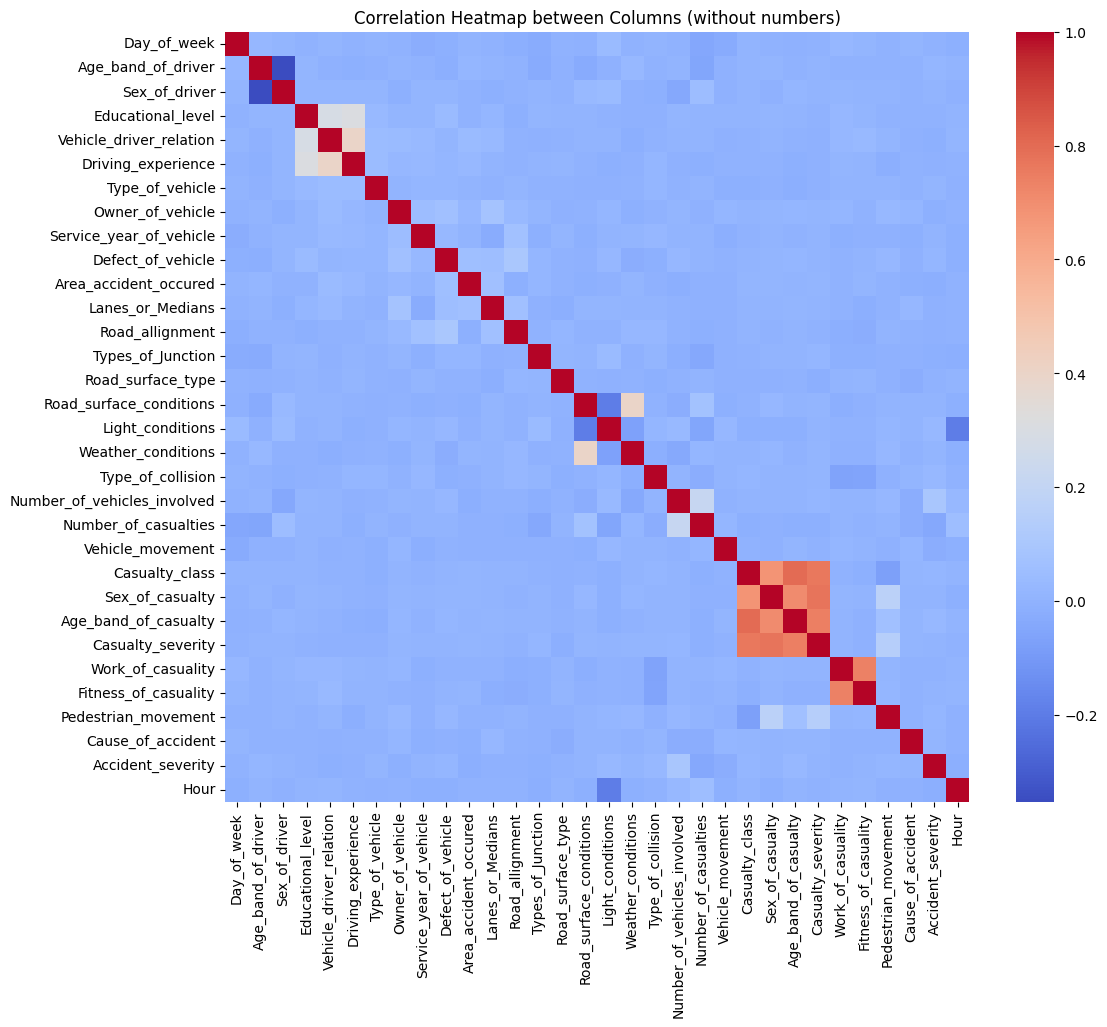

In [ ]:
correlation_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap between Columns (without numbers)")
plt.show()

In [ ]:
df.columns

Index(['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity', 'Hour'],
      dtype='object')

In [ ]:
X = df.drop(columns=["Accident_severity"])
y = df["Accident_severity"]

In [ ]:
from sklearn.model_selection import train_test_split


In [28]:
from sklearn.model_selection import train_test_split

if 'X' in locals() and 'y' in locals():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print("Data split into training and testing sets successfully.")
else:
    print("Error: X or y not defined. Run preprocessing cell first.")

Data split into training and testing sets successfully.


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.utils import class_weight
import numpy as np

if 'X_train' in locals():
    # 1. Random Forest
    model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
    model_rf.fit(X_train, y_train)

    # 2. KNN
    model_knn = KNeighborsClassifier(n_neighbors=5)
    model_knn.fit(X_train, y_train)

    # 3. XGBoost
    weights = class_weight.compute_sample_weight('balanced', y_train)
    model_xgb = xgb.XGBClassifier(n_estimators=100, random_state=42)
    model_xgb.fit(X_train, y_train, sample_weight=weights)
    print("Models trained successfully.")
else:
    print("Error: X_train not defined.")

Models trained successfully.


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# Ensure X_test and models exist
if 'X_test' in locals() and 'model_rf' in locals():
    # Generate predictions
    y_pred_rf = model_rf.predict(X_test)
    y_pred_knn = model_knn.predict(X_test)
    y_pred_xgb = model_xgb.predict(X_test)

    def get_metrics(y_true, y_pred, model_name):
        return {
            'Model': model_name,
            'Accuracy': accuracy_score(y_true, y_pred),
            'Macro Precision': precision_score(y_true, y_pred, average='macro'),
            'Macro Recall': recall_score(y_true, y_pred, average='macro'),
            'Macro F1': f1_score(y_true, y_pred, average='macro')
        }

    comparison_df = pd.DataFrame([
        get_metrics(y_test, y_pred_knn, 'KNN'),
        get_metrics(y_test, y_pred_rf, 'Random Forest'),
        get_metrics(y_test, y_pred_xgb, 'XGBoost')
    ])

    print("\n--- Model Performance Comparison ---")
    display(comparison_df)
else:
    print("Error: X_test or trained models not found. Please run the training cell 6d14f664 first.")


--- Model Performance Comparison ---


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,KNN,0.836615,0.380364,0.341597,0.332594
1,Random Forest,0.852775,0.413097,0.335091,0.311914
2,XGBoost,0.580645,0.387824,0.522234,0.360561


In [ ]:
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
np.unique(y_pred)

array([1, 2])

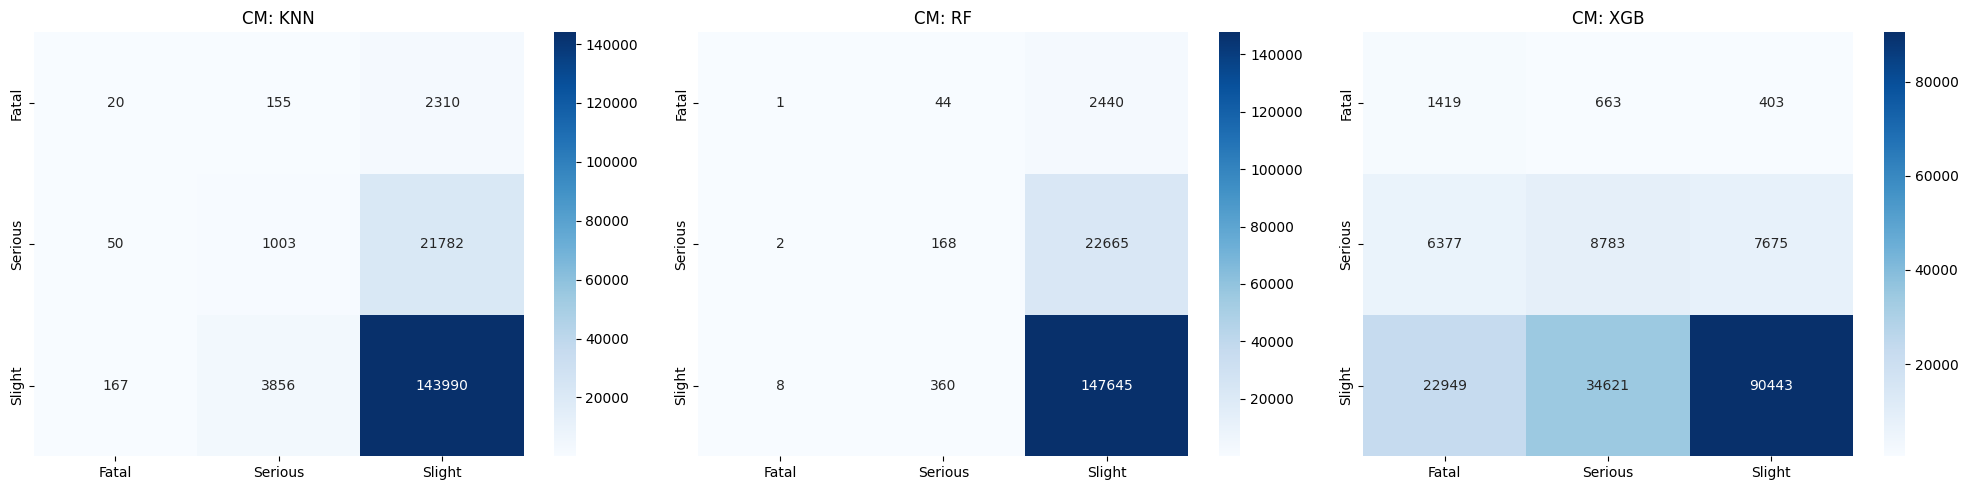

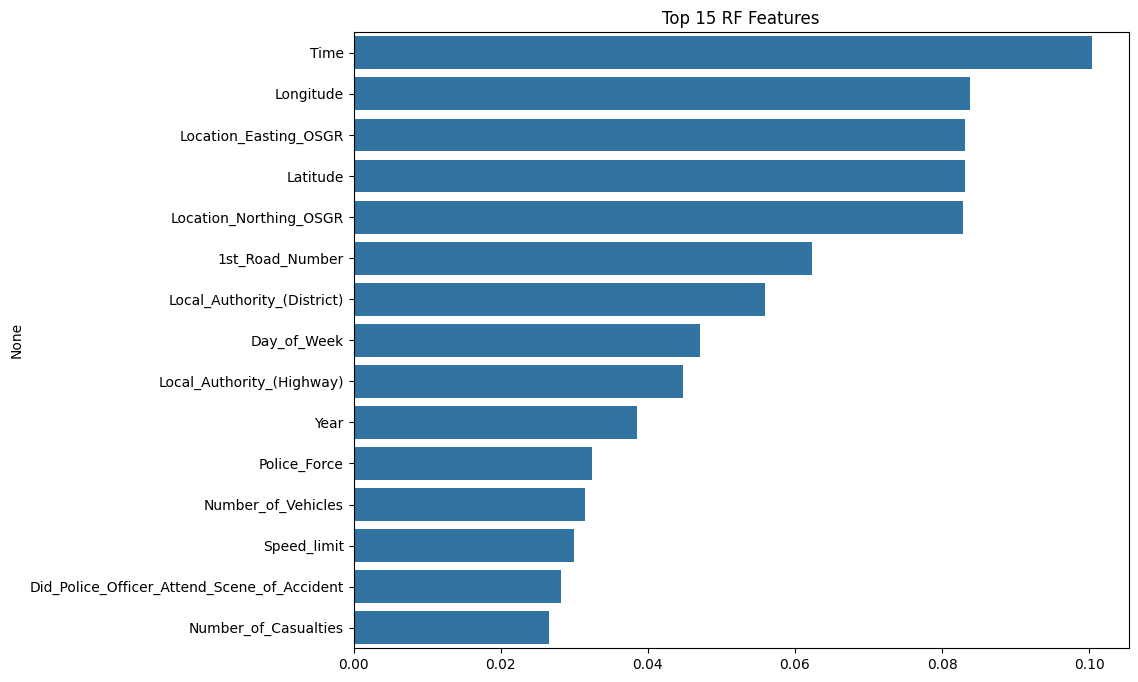

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

target_col = 'Accident_Severity'
if 'label_mappings' in locals() and target_col in label_mappings:
    target_names = [str(label_mappings[target_col][i]) for i in sorted(label_mappings[target_col].keys())]

    # Confusion Matrices
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    preds = [model_knn.predict(X_test), model_rf.predict(X_test), model_xgb.predict(X_test)]
    names = ['KNN', 'RF', 'XGB']

    for i, (pred, name) in enumerate(zip(preds, names)):
        cm = confusion_matrix(y_test, pred)
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', xticklabels=target_names, yticklabels=target_names)
        axes[i].set_title(f'CM: {name}')
    plt.tight_layout()
    plt.show()

    # Feature Importance (Random Forest)
    plt.figure(figsize=(10, 8))
    fi_rf = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
    sns.barplot(x=fi_rf.values, y=fi_rf.index)
    plt.title('Top 15 RF Features')
    plt.show()
else:
    print("Error: Preprocessing results not found.")

### **XGBoost Hyperparameter Tuning**
We will now use `RandomizedSearchCV` to find a better configuration for XGBoost, specifically targeting the **Macro F1-score** while maintaining the balanced class weights.

In [33]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb

# 1. Ensure Stratified Split for better evaluation of minority classes
if 'X' in locals() and 'y' in locals():
    X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 2. Calculate balanced sample weights for the training set
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_strat)

    # 3. Define the hyperparameter search space
    param_dist = {
        'n_estimators': [200, 300, 500],
        'max_depth': [3, 4, 5, 6],
        'learning_rate': [0.03, 0.05, 0.1],
        'min_child_weight': [1, 3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }

    xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

    # 4. Initialize Randomized Search
    # We use 12 iterations for a lightweight search
    random_search = RandomizedSearchCV(
        xgb_model,
        param_distributions=param_dist,
        n_iter=12,
        scoring='f1_macro',
        cv=StratifiedKFold(n_splits=3),
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    # 5. Fit with sample weights
    print("Starting Hyperparameter Tuning...")
    random_search.fit(X_train_strat, y_train_strat, sample_weight=sample_weights)

    best_xgb = random_search.best_estimator_
    print(f"Best Parameters Found: {random_search.best_params_}")
else:
    print("Variables X or y not found. Please run preprocessing cells first.")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [11:54:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters Found: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [34]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 6. Evaluate the Tuned Model
y_pred_tuned = best_xgb.predict(X_test_strat)

print("\n--- Tuned XGBoost Classification Report ---")
print(classification_report(y_test_strat, y_pred_tuned, target_names=target_names))

# 7. Update Comparison Table
def get_metrics_local(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro Precision': precision_score(y_true, y_pred, average='macro'),
        'Macro Recall': recall_score(y_true, y_pred, average='macro'),
        'Macro F1': f1_score(y_true, y_pred, average='macro')
    }

tuned_metrics = get_metrics_local(y_test_strat, y_pred_tuned, 'Tuned XGBoost')
final_comparison = pd.concat([comparison_df, pd.DataFrame([tuned_metrics])], ignore_index=True)

print("\n--- Final Model Comparison ---")
display(final_comparison)

# 8. Check Improvement
old_f1 = comparison_df[comparison_df['Model'] == 'XGBoost']['Macro F1'].values[0]
new_f1 = tuned_metrics['Macro F1']

if new_f1 > old_f1:
    print(f"\nSUCCESS: Macro F1 improved from {old_f1:.4f} to {new_f1:.4f}!")
else:
    print(f"\nNOTICE: Macro F1 did not improve significantly ({old_f1:.4f} vs {new_f1:.4f}).")


--- Tuned XGBoost Classification Report ---
              precision    recall  f1-score   support

       Fatal       0.05      0.51      0.09      2476
     Serious       0.20      0.41      0.27     22814
      Slight       0.92      0.62      0.74    148043

    accuracy                           0.59    173333
   macro avg       0.39      0.52      0.37    173333
weighted avg       0.81      0.59      0.67    173333


--- Final Model Comparison ---


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,KNN,0.836615,0.380364,0.341597,0.332594
1,Random Forest,0.852775,0.413097,0.335091,0.311914
2,XGBoost,0.580645,0.387824,0.522234,0.360561
3,Tuned XGBoost,0.593586,0.389237,0.515548,0.367199



SUCCESS: Macro F1 improved from 0.3606 to 0.3672!


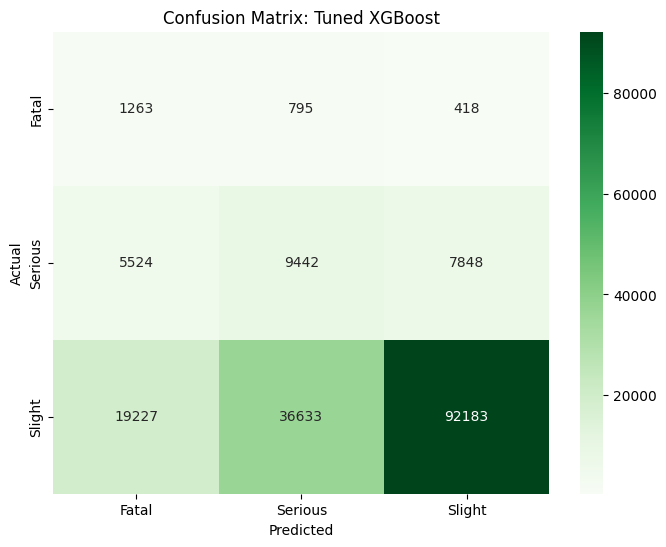

In [35]:
# 9. Visualize Tuned Confusion Matrix
plt.figure(figsize=(8, 6))
cm_tuned = confusion_matrix(y_test_strat, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Tuned XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
label_encoders = {}

# Loop through each categorical column and encode it
for column in non_numeric_columns.columns:
    le = LabelEncoder()  # Create a new encoder for each column
    df[column] = le.fit_transform(df[column])  # Encode column
    label_encoders[column] = le  # Store encoder for decoding later

In [ ]:
label_encoders

{'Day_of_week': LabelEncoder(),
 'Age_band_of_driver': LabelEncoder(),
 'Sex_of_driver': LabelEncoder(),
 'Educational_level': LabelEncoder(),
 'Vehicle_driver_relation': LabelEncoder(),
 'Driving_experience': LabelEncoder(),
 'Type_of_vehicle': LabelEncoder(),
 'Owner_of_vehicle': LabelEncoder(),
 'Service_year_of_vehicle': LabelEncoder(),
 'Defect_of_vehicle': LabelEncoder(),
 'Area_accident_occured': LabelEncoder(),
 'Lanes_or_Medians': LabelEncoder(),
 'Road_allignment': LabelEncoder(),
 'Types_of_Junction': LabelEncoder(),
 'Road_surface_type': LabelEncoder(),
 'Road_surface_conditions': LabelEncoder(),
 'Light_conditions': LabelEncoder(),
 'Weather_conditions': LabelEncoder(),
 'Type_of_collision': LabelEncoder(),
 'Vehicle_movement': LabelEncoder(),
 'Casualty_class': LabelEncoder(),
 'Sex_of_casualty': LabelEncoder(),
 'Age_band_of_casualty': LabelEncoder(),
 'Casualty_severity': LabelEncoder(),
 'Work_of_casuality': LabelEncoder(),
 'Fitness_of_casuality': LabelEncoder(),
 'Pe

In [ ]:
decoded_y_pred = [label_mappings['Accident_severity'][value] for value in y_pred]

In [ ]:
decoded_y_pred

['Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight I

In [ ]:
import pandas as pd

# Sample accident data for prediction
new_accident_data = pd.DataFrame({
    #'Speed': [40, 60, 80, 100, 50],
    'Weather_conditions': [0, 1, 2, 0, 2],  # Example: 0 = Clear, 1 = Rainy, 2 = Foggy
    'Road_surface_conditions': [1, 2, 0, 1, 2],  # Example: 0 = Dry, 1 = Wet, 2 = Icy
    'Hour': [9, 18, 23, 15, 21],  # Hour of accident
    'Minute': [15, 45, 10, 30, 50], # Minute of the hour

})

print(new_accident_data)


   Weather_conditions  Road_surface_conditions  Hour  Minute
0                   0                        1     9      15
1                   1                        2    18      45
2                   2                        0    23      10
3                   0                        1    15      30
4                   2                        2    21      50


In [ ]:
X_columns = X.columns.tolist()


In [ ]:
X_columns = X.columns.tolist()

#  Creating new_accident_data with initial columns
new_accident_data = pd.DataFrame({
    'Weather_conditions': [0, 1, 2, 0, 2],
    'Road_surface_conditions': [1, 2, 0, 1, 2],
    'Hour': [9, 18, 23, 15, 21],

})


for col in X_columns:
    if col not in new_accident_data.columns:
        new_accident_data[col] = X[col].mode()[0]

# Reorder columns to match X
new_accident_data = new_accident_data[X_columns]

# Encode categorical columns
for column in label_encoders:
    if column in new_accident_data.columns:

        new_accident_data[column] = new_accident_data[column].fillna(X[column].mode()[0])
        new_accident_data[column] = label_encoders[column].transform(new_accident_data[column])

print(new_accident_data)


   Day_of_week  Age_band_of_driver  Sex_of_driver  Educational_level  \
0            0                   0              1                  4   
1            0                   0              1                  4   
2            0                   0              1                  4   
3            0                   0              1                  4   
4            0                   0              1                  4   

   Vehicle_driver_relation  Driving_experience  Type_of_vehicle  \
0                        0                   2                0   
1                        0                   2                0   
2                        0                   2                0   
3                        0                   2                0   
4                        0                   2                0   

   Owner_of_vehicle  Service_year_of_vehicle  Defect_of_vehicle  ...  \
0                 3                        6                  2  ...   
1                 3 

In [ ]:


# Predict accident severity
predicted_severity = model.predict(new_accident_data)



In [ ]:
decoded_severity = [label_mappings['Accident_severity'][value] for value in predicted_severity]


In [ ]:
predicted_severity

array([2, 2, 2, 2, 2])

In [ ]:
decoded_severity

['Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury',
 'Slight Injury']